In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
food = pd.read_csv('C:/Users/USER/Desktop/연습데이터/연습문제 데이터/data/matzipData.csv', header=0)

In [38]:
food

,Restaurant Name,Rating,Address,Tel,Food,Price,Parking,Operating Time,Holiday
0,이나니와요스케,4.4,서울시 중구 을지로1가 192-11,02-772-9994,라멘 / 소바 / 우동,만원-2만원,주차공간없음,11:00 - 23:00,일
1,바오차이,4.4,서울시 중구 을지로2가 203,02-6031-0107,정통 중식 / 일반 중식,2만원-3만원,유료주차 가능,11:30 - 21:30,NaN
2,라칸티나,4.4,서울시 중구 을지로1가 50,02-777-2579,이탈리안,3만원-4만원,NaN,월-토: 11:30 - 23:00 일: 17:30 - 23:00,NaN
3,라세느,4.3,서울시 중구 소공동 1,02-317-7171,뷔페,4만원 이상,발렛,06:00 - 22:00,NaN
4,산수갑산,4.3,서울시 중구 인현동1가 15-4,02-2275-6654,탕 / 찌개 / 전골,만원 미만,유료주차 가능,월-금: 11:30 - 22:00 토: 11:30 - 20:00,일
...,...,...,...,...,...,...,...,...,...
395,누룩나무,4,서울시 종로구 관훈동 118-19,02-722-3398,전통 주점 / 포차,만원-2만원,주차공간없음,17:00 - 01:30,일
396,옴,4,서울시 종로구 신문로1가 2,02-723-4848,인도 음식,만원-2만원,주차공간없음,11:00 - 22:00,NaN
397,코블러,4,서울시 종로구 내자동 157,02-733-6421,칵테일 / 와인,만원-2만원,유료주차 가능,19:00 - 03:00,일
398,클류치,4,서울시 종로구 명륜3가 79-1,010-2702-1496,카페 / 디저트,만원 미만,주차공간없음,월-토: 10:00 - 23:00 일: 11:00 - 20:00,NaN


In [39]:
# 1. 데이터 크기, 기본구조 확인하기
food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Restaurant Name  400 non-null    object
 1   Rating           400 non-null    object
 2   Address          400 non-null    object
 3   Tel              350 non-null    object
 4   Food             400 non-null    object
 5   Price            397 non-null    object
 6   Parking          329 non-null    object
 7   Operating Time   364 non-null    object
 8   Holiday          126 non-null    object
dtypes: object(9)
memory usage: 28.2+ KB


In [40]:
food.head(5)

,Restaurant Name,Rating,Address,Tel,Food,Price,Parking,Operating Time,Holiday
0,이나니와요스케,4.4,서울시 중구 을지로1가 192-11,02-772-9994,라멘 / 소바 / 우동,만원-2만원,주차공간없음,11:00 - 23:00,일
1,바오차이,4.4,서울시 중구 을지로2가 203,02-6031-0107,정통 중식 / 일반 중식,2만원-3만원,유료주차 가능,11:30 - 21:30,NaN
2,라칸티나,4.4,서울시 중구 을지로1가 50,02-777-2579,이탈리안,3만원-4만원,NaN,월-토: 11:30 - 23:00 일: 17:30 - 23:00,NaN
3,라세느,4.3,서울시 중구 소공동 1,02-317-7171,뷔페,4만원 이상,발렛,06:00 - 22:00,NaN
4,산수갑산,4.3,서울시 중구 인현동1가 15-4,02-2275-6654,탕 / 찌개 / 전골,만원 미만,유료주차 가능,월-금: 11:30 - 22:00 토: 11:30 - 20:00,일


In [41]:
# 2. 결측값 처리
food['Holiday'].isnull().sum()

274

In [42]:
# 2-1 결측값 처리
food['Holiday'].fillna('연중무휴', inplace = True)

In [43]:
food['Holiday'].isnull().sum() #or values_counts()

0

In [44]:
# 3 price 가격 정리

In [45]:
# 3 - 1
food['Price'].isnull().sum()

3

In [46]:
food['Price'] = food['Price'].fillna(10000)

In [47]:
food['Price'].isnull().sum()

0

In [48]:
food['Price'].value_counts()

만원-2만원     161
만원 미만      159
2만원-3만원     46
4만원 이상      22
3만원-4만원      9
10000        3
Name: Price, dtype: int64

In [49]:
# 가격을 범위에 따라 특정 숫자로 지정하기
food['Price'] = food['Price'].replace({'만원 미만':1000, '만원-2만원':10000, '2만원-3만원':20000,
                                      '3만원-4만원':30000, '4만원 이상':40000})

In [51]:
food['Price']

0      10000
1      20000
2      30000
3      40000
4       1000
       ...  
395    10000
396    10000
397    10000
398     1000
399     1000
Name: Price, Length: 400, dtype: int64

In [52]:
#4 별점 데이터 정리
food['Rating'].value_counts()

-      155
4       53
4.1     47
4.2     40
4.3     37
4.4     20
4.5      9
3.9      7
3.7      6
4.6      5
3.3      5
3.6      4
3.4      4
4.7      3
3.8      2
3.2      1
3.1      1
2.7      1
Name: Rating, dtype: int64

In [54]:
# '-' 값 0으로 치환
food['Rating'] = food['Rating'].replace({'-': 0.0})

In [55]:
#변환후 확인하기
food['Rating'].value_counts()

0.0    155
4       53
4.1     47
4.2     40
4.3     37
4.4     20
4.5      9
3.9      7
3.7      6
4.6      5
3.3      5
3.6      4
3.4      4
4.7      3
3.8      2
3.2      1
3.1      1
2.7      1
Name: Rating, dtype: int64

In [64]:
#혹시 모르니 숫자형으로 처리
food['Rating'] = food['Rating'].astype(float)


In [68]:
print(np.mean(food['Rating']))
print(np.max(food['Rating']))
print(np.min(food['Rating']))

2.520000000000006
4.7
0.0


(array([159.,   0., 164.,   0.,  46.,   0.,   0.,   9.,   0.,  22.]),
 array([ 1000.,  4900.,  8800., 12700., 16600., 20500., 24400., 28300.,
        32200., 36100., 40000.]),
 <BarContainer object of 10 artists>)

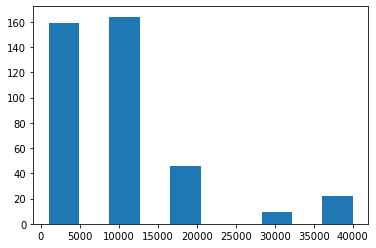

In [70]:
# 6. 간단한 시각화
# 6-1 hist 그리기
plt.hist(food['Price'])

(array([155.,   0.,   0.,   0.,   0.,   1.,   2.,  19., 149.,  74.]),
 array([0.  , 0.47, 0.94, 1.41, 1.88, 2.35, 2.82, 3.29, 3.76, 4.23, 4.7 ]),
 <BarContainer object of 10 artists>)

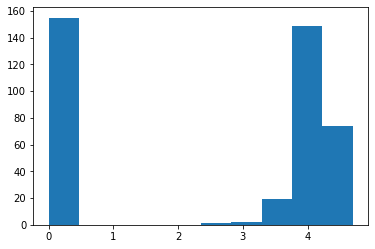

In [71]:
plt.hist(food['Rating'])

<AxesSubplot:xlabel='Rating', ylabel='Price'>

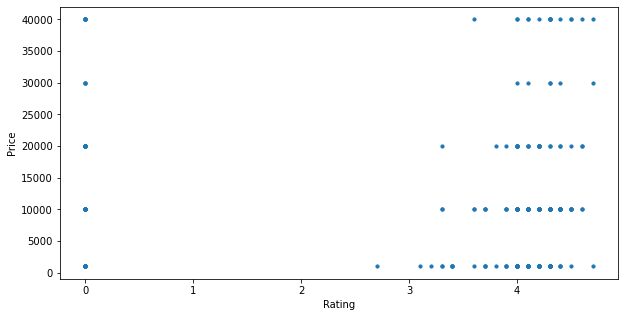

In [75]:
food.plot(kind='scatter', x='Rating', y='Price', s=10, figsize=(10,5))

In [79]:
#7별점이 4.4이상이고 가격이 1만원 이하인 식당 필터링
food[(food['Price'] < 10000) & (food['Rating'] >= 4.4)]

,Restaurant Name,Rating,Address,Tel,Food,Price,Parking,Operating Time,Holiday
201,폴앤폴리나,4.7,서울시 종로구 내수동 74,02-739-5520,베이커리,1000,유료주차 가능,12:00 - 19:00,"일, 첫째 월"
213,파네트크루아상팩토리,4.5,서울시 종로구 내수동 71,NaN,카페 / 디저트,1000,NaN,NaN,연중무휴
220,오뗄두스,4.4,서울시 중구 태평로1가 84,070-4221-5705,카페 / 디저트,1000,유료주차 가능,09:30 - 21:30,연중무휴
228,무교동북어국집,4.4,서울시 중구 다동 173,02-777-3891,탕 / 찌개 / 전골,1000,주차공간없음,07:00 - 20:00,연중무휴
232,국수찾아닭만리,4.4,서울시 종로구 낙원동 110,02-745-4079,닭 / 오리 요리,1000,주차공간없음,16:30 - 24:00,일


In [80]:
#카페 디저트가 많다

In [98]:
# 8 음식 종류별 분석
food1 = food.set_index('Food')[['Rating', 'Price']]

In [99]:
# 확인하기
food1

,Rating,Price
Food,,
라멘 / 소바 / 우동,4.4,10000
정통 중식 / 일반 중식,4.4,20000
이탈리안,4.4,30000
뷔페,4.3,40000
탕 / 찌개 / 전골,4.3,1000
...,...,...
전통 주점 / 포차,4.0,10000
인도 음식,4.0,10000
칵테일 / 와인,4.0,10000


In [100]:
# 자세히 보기
food1.value_counts('Food')

Food
카페 / 디저트            68
고기 요리               42
한정식 / 백반 / 정통 한식    25
탕 / 찌개 / 전골         25
이탈리안                24
기타 한식               20
국수 / 면 요리           15
치킨 / 호프 / 펍         14
닭 / 오리 요리           13
베이커리                11
칵테일 / 와인            10
정통 중식 / 일반 중식       10
브런치 / 버거 / 샌드위치      9
세계음식 기타              9
정통 일식 / 일반 일식        8
해산물 요리               8
기타 중식                7
라멘 / 소바 / 우동         7
회 / 스시               6
돈부리 / 일본 카레 / 벤토     6
스테이크 / 바베큐           5
인도 음식                5
일반 주점                5
베트남 음식               5
태국 음식                4
기타 양식                4
기타 일식                4
프랑스 음식               4
퓨전 양식                4
까스 요리                4
뷔페                   3
다국적 아시아 음식           3
전통 주점 / 포차           3
남미 음식                2
퓨전 일식                2
퓨전 중식                2
이자카야 / 오뎅 / 꼬치       2
패밀리 레스토랑             1
딤섬 / 만두              1
dtype: int64

In [101]:
# Food를 column으로 옮기기
food1 = food1.reset_index()
food1 = food1.rename(columns={'index':'Food'})

In [102]:
food1

,Food,Rating,Price
0,라멘 / 소바 / 우동,4.4,10000
1,정통 중식 / 일반 중식,4.4,20000
2,이탈리안,4.4,30000
3,뷔페,4.3,40000
4,탕 / 찌개 / 전골,4.3,1000
...,...,...,...
395,전통 주점 / 포차,4.0,10000
396,인도 음식,4.0,10000
397,칵테일 / 와인,4.0,10000
398,카페 / 디저트,4.0,1000


In [ ]:
# 8-2 종류별 분석 해보기

In [104]:
food1[(food1['Food'] == '라멘 / 소바 / 우동')]

,Food,Rating,Price
0,라멘 / 소바 / 우동,4.4,10000
33,라멘 / 소바 / 우동,3.4,1000
34,라멘 / 소바 / 우동,3.4,1000
91,라멘 / 소바 / 우동,0.0,1000
146,라멘 / 소바 / 우동,0.0,1000
338,라멘 / 소바 / 우동,4.1,1000
364,라멘 / 소바 / 우동,4.0,1000


In [105]:
food1[(food1['Food'] == '탕 / 찌개 / 전골')]

,Food,Rating,Price
4,탕 / 찌개 / 전골,4.3,1000
28,탕 / 찌개 / 전골,3.7,10000
76,탕 / 찌개 / 전골,0.0,10000
90,탕 / 찌개 / 전골,0.0,10000
97,탕 / 찌개 / 전골,0.0,1000
101,탕 / 찌개 / 전골,0.0,10000
107,탕 / 찌개 / 전골,0.0,10000
113,탕 / 찌개 / 전골,0.0,10000
115,탕 / 찌개 / 전골,0.0,10000
123,탕 / 찌개 / 전골,0.0,1000


In [111]:
#한글 폰트 설치
from matplotlib import font_manager, rc
font_path = "C:/Windows/Fonts/malgun.ttf"   
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

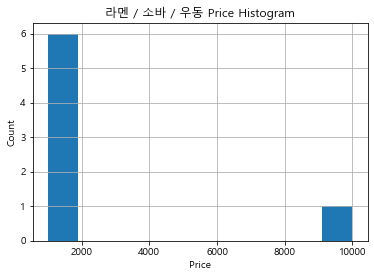

In [122]:
target = "라멘 / 소바 / 우동"
food1[food1['Food'] == target]['Price'].hist()
plt.xlabel('Price')
plt.ylabel('Count')
plt.title(f'{target} Price Histogram')
plt.show()

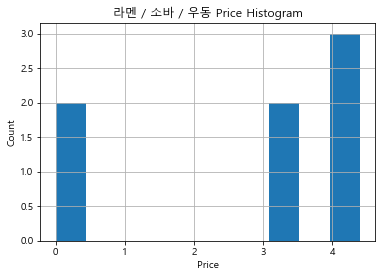

In [125]:
target = "라멘 / 소바 / 우동"
food[food['Food'] == target]['Rating'].hist()
plt.xlabel('Price')
plt.ylabel('Count')
plt.title(f'{target} Price Histogram')
plt.show()

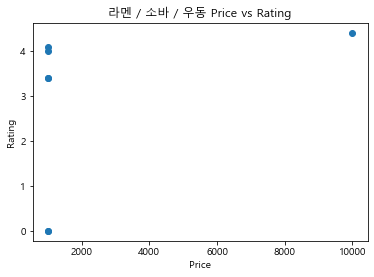

In [126]:
target = "라멘 / 소바 / 우동"
subset = food[food['Food'] == target]

plt.scatter(subset['Price'], subset['Rating'])
plt.xlabel('Price')
plt.ylabel('Rating')
plt.title(f'{target} Price vs Rating')
plt.show()

In [127]:
# 9 마무리 
# 별점 높고 싼 가게가 최고다
# 전처리를 대충 했더니 좋은 결과가 나오지 않는다

In [162]:
#확장 과제 
food = pd.read_csv('C:/Users/USER/Desktop/연습데이터/연습문제 데이터/data/matzipData.csv', header=0)

In [163]:
food2 = food
food2.head()

,Restaurant Name,Rating,Address,Tel,Food,Price,Parking,Operating Time,Holiday
0,이나니와요스케,4.4,서울시 중구 을지로1가 192-11,02-772-9994,라멘 / 소바 / 우동,만원-2만원,주차공간없음,11:00 - 23:00,일
1,바오차이,4.4,서울시 중구 을지로2가 203,02-6031-0107,정통 중식 / 일반 중식,2만원-3만원,유료주차 가능,11:30 - 21:30,NaN
2,라칸티나,4.4,서울시 중구 을지로1가 50,02-777-2579,이탈리안,3만원-4만원,NaN,월-토: 11:30 - 23:00 일: 17:30 - 23:00,NaN
3,라세느,4.3,서울시 중구 소공동 1,02-317-7171,뷔페,4만원 이상,발렛,06:00 - 22:00,NaN
4,산수갑산,4.3,서울시 중구 인현동1가 15-4,02-2275-6654,탕 / 찌개 / 전골,만원 미만,유료주차 가능,월-금: 11:30 - 22:00 토: 11:30 - 20:00,일


In [164]:
food2['Price'].value_counts()

만원-2만원     161
만원 미만      159
2만원-3만원     46
4만원 이상      22
3만원-4만원      9
Name: Price, dtype: int64

In [165]:
# 가격을 범위에 따라 랜덤하게(단위 천원) 배치
# 결측은 10000으로 대체하기
def rand1000(x, y):
    return np.random.choice(np.arange(x, y, 1000))

In [166]:
def price_num(x):
    if x == '만원 미만':
        return rand1000(7000, 10000)
    elif x == '만원-2만원':
        return rand1000(10000, 20000)
    elif x == '2만원-3만원':
        return rand1000(20000, 30000)
    elif x == '3만원-4만원':
        return rand1000(30000, 40000)
    elif x == '4만원 이상':
        return rand1000(40000, 100000)
    else:
        return 10000

In [167]:
food2['Price'] = food2['Price'].apply(price_num)

In [168]:
food2['Price']

0      17000
1      22000
2      31000
3      82000
4       9000
       ...  
395    15000
396    18000
397    17000
398     8000
399     9000
Name: Price, Length: 400, dtype: int64

In [154]:
# 별점 결측치를 중앙값으로 대체

In [169]:
food2['Rating'] = pd.to_numeric(food2['Rating'], errors='coerce')

In [170]:
median_rating = food['Rating'].median()
food['Rating'] = food['Rating'].fillna(median_rating)

In [171]:
food2['Rating'] = food2['Rating'].astype(float)

<AxesSubplot:>

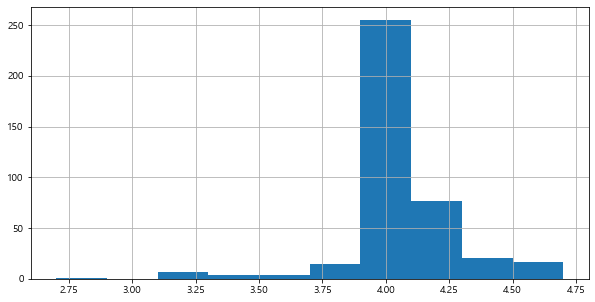

In [196]:
food2['Rating'].hist(figsize=(10,5))

In [172]:
food2['Rating'].value_counts()

4.1    202
4.0     53
4.2     40
4.3     37
4.4     20
4.5      9
3.9      7
3.7      6
3.3      5
4.6      5
3.6      4
3.4      4
4.7      3
3.8      2
3.2      1
3.1      1
2.7      1
Name: Rating, dtype: int64

In [173]:
corr = food2['Rating'].corr(food2['Price'])
print(corr)

0.17768209459538906


In [160]:
# 상관 관계가 아주 낮다


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


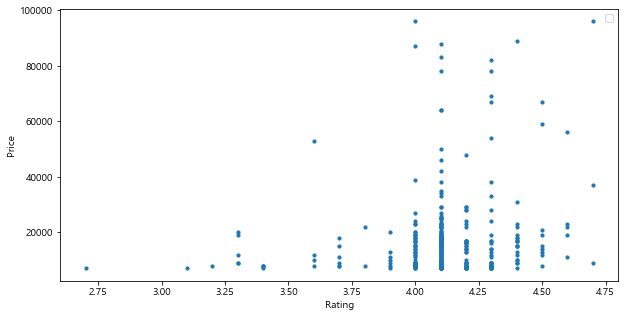

In [188]:
food2.plot(kind='scatter', x='Rating', y='Price', s=10, figsize=(10,5))
plt.legend()

In [ ]:
plt.scatter()

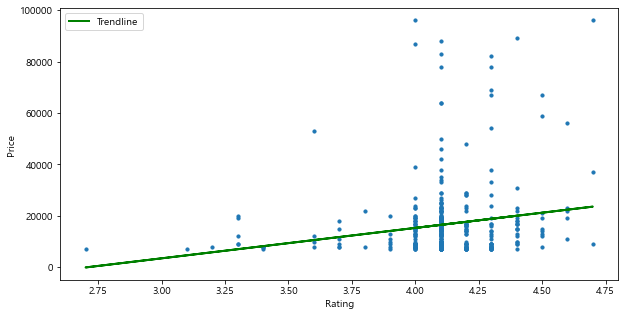

In [193]:

x = food2['Rating']
y = food2['Price']
plt.figure(figsize=(10,5))
plt.scatter(x, y, s=10)

# 회귀 계수 계산
m, b = np.polyfit(x, y, 1)   # 1차 회귀
plt.plot(x, m*x + b, color='green', linewidth=2, label='Trendline')

plt.xlabel('Rating')
plt.ylabel('Price')
plt.legend()
plt.show()